In [1]:
import chess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir("/sfs/gpfs/tardis/home/zrc3hc/CHESS_RL_RIV")

# Learning to Play Chess via Self-Play Reinforcement Learning
## Lizzy Miller
### April 28th, 2025
-----
## 0. Contents

1. Overview
2. State Representation and Action Space
3. The Opponent
4. Model and Algorithm
5. Model Performance
6. Next Steps


-----

## 1. Overview

* **Goal: Create a chess engine that learns to play chess!**

    
In this project, I developed a chess engine that uses reinforcement learning to improve its decision-making over time by playing thousands of games against an evolving opponent.

* **Learning Objective**: 
    * The engine needs to learn the relative values of pieces (e.g., pawns, knights, queens) purely though experience--meaning it is not told how much each piece is worth. 
    * The engine should also be learning the correlations between piece placement and outcomes: 
        * Even without explicit spatial knowledge, the model hsould gradually learn that having certain pieces on certain squares (e.g., a pawn in the middel) correlates with better rewards or winning outcomes. 

* **Training Perspective**: 
    * The engine learns from the White player's perspective only. 
    
-----

## 2. State Representation and Action Space

* The environment is a standard chessboard.

* The agent only receives partial information about the environment.

* The action space is a list of all available moves that the white engine can make. 

* Therefore, the agent is acting dynamically in a changing environment. 

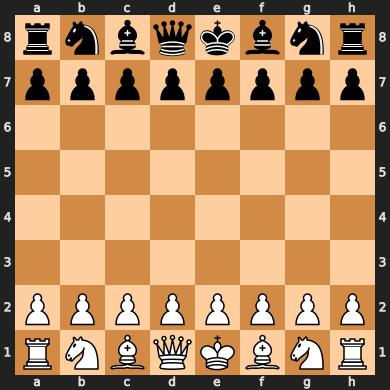

In [2]:
chess.Board()

----
The model does not have access to the full board layout directly. Instead, it interacts with the environment by evaluating the legal moves available at each step.

### 2.a How the Model Perceives the Environment

1. The legal moves available to the white engine at the given position
2. The material difference of the board. 
3. If white is checkmated.
----

In [3]:
## Example
#board.reset()
board = chess.Board()
legal_moves = list(board.legal_moves)
moves = [move.uci() for move in legal_moves]
print("Example:")
print()
print("=== ACTION SPACE ===")
for move in moves:
    print(move)
    
board = chess.Board()
legal_moves = list(board.legal_moves)
moves = [move.uci() for move in legal_moves]


print()
print("=== CURRENT STATE FEATURES ===")
print()
print("Material Difference of the Position: 0 Points")

print()
print("== Is white in checkmate OR draw?==")
print("No (if yes then game ends).")

Example:

=== ACTION SPACE ===
g1h3
g1f3
b1c3
b1a3
h2h3
g2g3
f2f3
e2e3
d2d3
c2c3
b2b3
a2a3
h2h4
g2g4
f2f4
e2e4
d2d4
c2c4
b2b4
a2a4

=== CURRENT STATE FEATURES ===

Material Difference of the Position: 0 Points

== Is white in checkmate OR draw?==
No (if yes then game ends).


== EXAMPLE CONTINUED ==



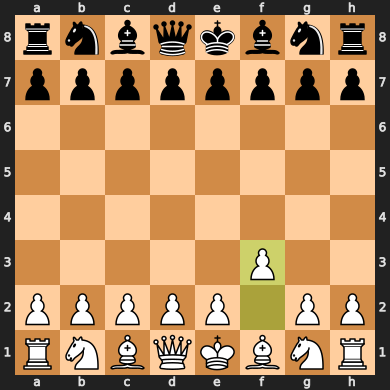

In [4]:
## Example

print("== EXAMPLE CONTINUED ==")
print()

board = chess.Board()
Pf2f3 = chess.Move.from_uci("f2f3")
board.push(Pf2f3)

board

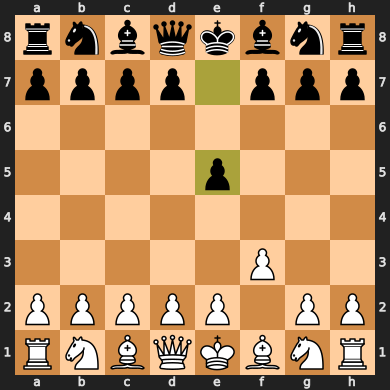

In [5]:
## Example
Pe7e5 = chess.Move.from_uci("e7e5")
board.push(Pe7e5)

board

In [6]:
legal_moves = list(board.legal_moves)
moves = [move.uci() for move in legal_moves]
print("Legal Moves from Next Position:")
for move in moves:
    print(move)
    
print()
print("Material Difference of the Position")
print("Material Difference: 0")

print()
print("Is white in checkmate?")
print("no")

Legal Moves from Next Position:
g1h3
e1f2
b1c3
b1a3
f3f4
h2h3
g2g3
e2e3
d2d3
c2c3
b2b3
a2a3
h2h4
g2g4
e2e4
d2d4
c2c4
b2b4
a2a4

Material Difference of the Position
Material Difference: 0

Is white in checkmate?
no


--- 
### 2.b. What does the engine *not see*?

The model does not explicitly know how much each piece is worth.

- For example, it can evaluate that the material difference is +1 point, but it will not know (at least in the beginning) that capturing a pawn is worth 1 point.
- The model is expected to **learn the relative value of pieces** through experience.

In addition, the model does not explicitly know **which pieces are on which squares**.
- It only knows the available moves. (e.g., it knows that it can move a piece to the c3 square but does not explicitly know which piece is moving.)
- The model must **infer spatial and piece identity information** through training over time.

---

### 2.c. As a result, the model is not designed to explicitly consider strategies/heuristics like:


- Positional factors (e.g., "Is a rook on an open file?")
- King safety
- Center control
- Piece activity
- Tactical threats (e.g., forks, pins, skewers)

---

## 3. The Opponent

Also part of the environment is the opponent, which in this case is the **Black Engine**.

The White engine learns through **self-play**.

The opponent has a slight advantage in that:

- **The Black Engine has access to piece value knowledge — it selects moves based on a simple evaluation of material balance (e.g., pawns = 1, queens = 9).**

- This gives Black an early advantage during the initial learning stages.  
  - For example, the White engine does not initially realize that trading its queen for a pawn is a poor exchange.

In addition, the opponent's behavior is **not explicitly modeled** by the agent.  
- The White engine does not directly observe whether the opponent moved a pawn or a knight to a given square — it only sees the available legal moves and the resulting board state.

Instead, the opponent's moves are treated as part of the **environment’s natural transition dynamics**.

The Black engine does **not learn independently**.  
However, every **5000 games**, it updates its weights to match the White engine's current weights.  
This mechanism makes the opponent progressively stronger over time, encouraging the White engine to continue improving.

---

**Summary Takeaway**:  
The Black engine provides a consistent but evolving challenge for the White engine.  
The White engine must learn purely from the environment's responses without modeling the opponent explicitly.


---

This game of chess closely resembles the 'Fog of War' variant of chess: https://www.chess.com/variants/fog-of-war

---

## 4. Model/Algorithm

**Overview**: The aim of learning is for the model to learn the values of the chess pieces

* **Model Type:**
    * Simple linear model -- no neural networks
    * Weight Vector: 391-dimensions 
    

* $\epsilon$-greedy policy 
    * Exploration at a rate of 0.01 with a decay of 0.999 every 100 games played

* **Learning Algorithm:**
    * Q-learning with Temporal Difference (TD) error.

---

### 4.a Model Architecture


The model's architecture is delibertly simple to focus learning purely on reward signals rather than on a complex board encoding. 

* Each game had a limit of 300 max moves to prevent endless games. 
* A game stops during checkmate or draws according to standard chess, including:
    * Stalemate
    * 75 move rule
    * Insufficient Material
    * Fivefold repitition 

**Rewards:**
* (+ 100) for Winning
* (- 100) for Losing 
* (0) for Draws or Max moves reached.


--- 

Below is an example of how the model considers moves: 



In [7]:
class MiniLearningEngine:
    def __init__(self):
        self.weights = np.random.randn(7)  # Start with random weights
        self.learning_rate = 0.01
        self.discount = 1.0
        self.buffer = []  # Simple buffer for now

    def features(self, board):
        """Very simple feature: material count for the player to move."""
        piece_values = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0}
        material = 0
        for square, piece in board.piece_map().items():
            value = piece_values[piece.piece_type]
            material += value if piece.color == board.turn else -value
        return np.array([material, 0, 0, 0, 0, 0, 0])  
    
    def action_score(self, board, move):
        board.push(move)
        descriptor = self.features(board)
        board.pop()
        return np.dot(self.weights, descriptor)

    def q_learn(self, reward, prev_board, prev_move, new_board):
        prev_board.push(prev_move)
        descriptor = self.features(prev_board)
        prev_board.pop()

        moves = list(new_board.legal_moves)
        if moves:
            max_future_score = max([self.action_score(new_board, move) for move in moves])
        else:
            max_future_score = 0

        prediction = self.action_score(prev_board, prev_move)
        target = reward + self.discount * max_future_score
        td_error = target - prediction

        self.weights += self.learning_rate * td_error * descriptor

        print(f"TD Error: {td_error:.4f}")
        print(f"Updated Weights: {self.weights}")

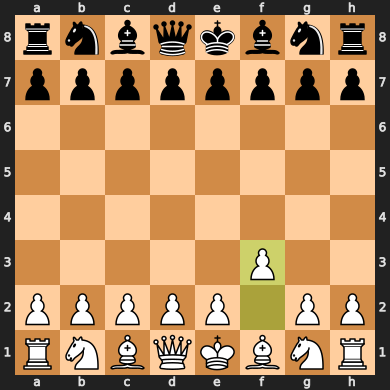

In [8]:
# Initialize board and engine
engine = MiniLearningEngine()
board = chess.Board()
prev_board = chess.Board()

# Make a simple move: White plays e2e4
move = chess.Move.from_uci("f2f3")
board.push(move)

board

Then the black engine responds

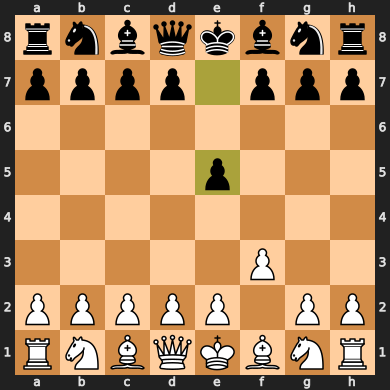

In [9]:
# Black plays e7e5
board.push(chess.Move.from_uci("e7e5"))
board

After the black engine makes a move, it's White's turn again:
* The white engine searches the new board state for its next action. 
* If the model chooses exploitation, it evaluates each legal move and:
    * It images making that move.
    * Extracts **features** from the resulting board
    * Applies its learned weights to score the move (from a linear model)

Each move recieves a score that estimates how favorable that new board position is. 

The move with the highest score is selected for exploitation. 

The model is actively learning how to assign high scores to moves that lead to material gains, favoriable board control or checkmate--and low scores to move that lead to losses. 

---

Below is an example of how the model extracts and evaluates **features**.

Suppose the white engine will evaluate this as a **theroetical position**:

---
**Step 1. The model imagines making move g2g4**
---

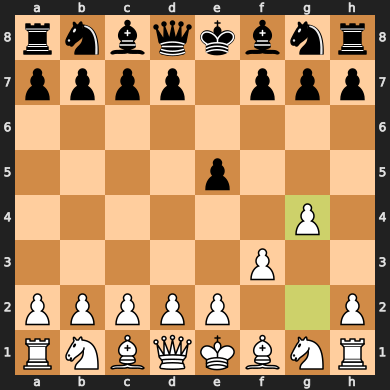

In [10]:

prev_board = board
board.push(chess.Move.from_uci("g2g4"))
board

---
**Step 2. Extract relevant features from the board such as**
---

**a. Global Features** 

| Feature | Value| Reason |
| --------| --------|--------|
| Pawn | 0 | Equal Pawns |
| Knight | 0| Equal Knights |
| Bishop | 0 | Equal Bishops |
| Rook | 0 | Equal Rooks |
| Queen | 0 | Equal Queens |
| King | 0 | Equal Kings |
| Checkmate | 0 | (Not in checkmate)
---
**b. Piece-grid Feautures (384)**

The peice-gird is a sparse 64.6 matrix, where each row corresponds to a square (indexed from a1 to h8) and each column corresponds to a piece type (pawn, knight, bishop, rook, queen, king). The values are -1 for player's pieces, +1 for opponents pieces, and 0 otherwise.

In [11]:
all_pieces = board.piece_map().items()
features = np.zeros(7)
        
index = {
    chess.PAWN: 0,
    chess.KNIGHT: 1,
    chess.BISHOP: 2,
    chess.ROOK: 3,
    chess.QUEEN: 4,
    chess.KING: 5
}

piece_grid = np.zeros((64, 6))



for position, piece in all_pieces:
    value = -1 if piece.color == board.turn else 1

    type_index = index[piece.piece_type]

    features[index[piece.piece_type]] += value


    piece_grid[position, type_index] = value

In [12]:
piece_grid

array([[ 0.,  0.,  0.,  1.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.],
       [ 0.,  0.,  1.,  0.,  0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0

**c. The White Engine will Check if the Black Engine is in Checkmate.**

* If white move results in checkmate, then it'll pick the move


---
**Step 3. The Engine Computes the Move Score**
---



After evaluating the new move, the model assigns a score to the resulting board state using a linear model:

$$
\text{Score of Move} = \theta^T \times \text{Features(board)}
$$

After repeating this process for all available legal moves, the White engine selects the move that maximizes its predicted score.


(*Example Continued*) Suppose the model picks below as their next move.

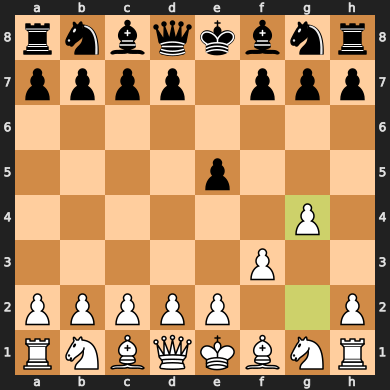

In [13]:
board

And black responds with.

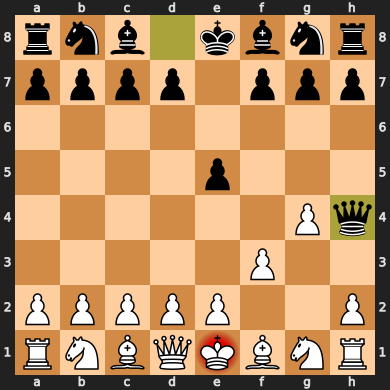

In [14]:
board.push(chess.Move.from_uci("d8h4"))
board

This is checkmate so now the game is over.


#### 4.a.a What happens once a game is finished?

1. The model stores a record of all the board positions and moves it made during the game into a **Prioritized Replay Buffer**. (batchsize = 10)
2. Each experience is assigned a priority based on its immediate reward and updated over time based on the temporal difference (TD) error.
3. After accumulating enough experiences, the model samples a batch of important moves — favoring moves with higher priority — and applies **Q-learning updates**.
4. Specifically, for each sampled experience, the model uses the TD error between the predicted move value and the updated target to adjust its weights.
5. This process reinforces moves that led to favorable outcomes (material gain, checkmate) and penalizes moves that resulted in material loss or defeat.
6. Additionally, the final move of the game receives a large reward or penalty depending on whether the model won, lost, or drew the game.

---

Thus, in this particular game, the model likely learned that pushing a pawn to f3 leads to poor outcomes — and will gradually reduce the value of moves that lead to similar positions over time. However, because updates happen through prioritized sampling, the learning focuses more heavily on moves that caused major changes in reward or outcome.


# 5. Model Performance

* The model was trained over 120,000 total games
* The model trained for over 18 hours

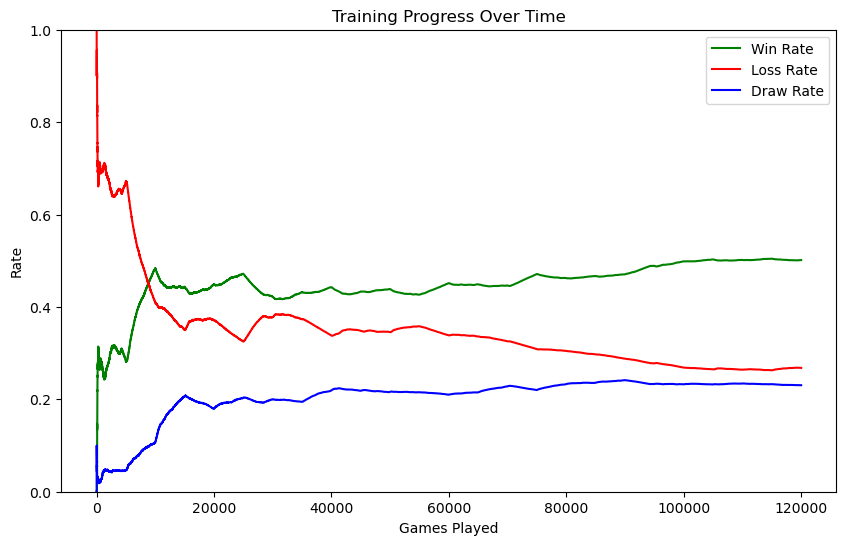

In [15]:
results = pd.read_csv('mf2_results/results.csv')

# Compute Cumulative Results

games = np.arange(1, len(results) + 1)
win_rate = results["Wins"].cumsum() / games
loss_rate = results["Losses"].cumsum() / games
draw_rate = results["Draws"].cumsum() / games

# Plot
plt.figure(figsize=(10, 6))
plt.plot(games, win_rate, label='Win Rate', color='green')
plt.plot(games, loss_rate, label='Loss Rate', color='red')
plt.plot(games, draw_rate, label='Draw Rate', color='blue')

plt.title('Training Progress Over Time')

plt.xlabel('Games Played')
plt.ylabel('Rate')
plt.ylim(0, 1)
plt.legend()
#plt.savefig('plots/training_progress.png')
plt.show()

#### Is the white model getting stronger or is the opponent just getting easier? 

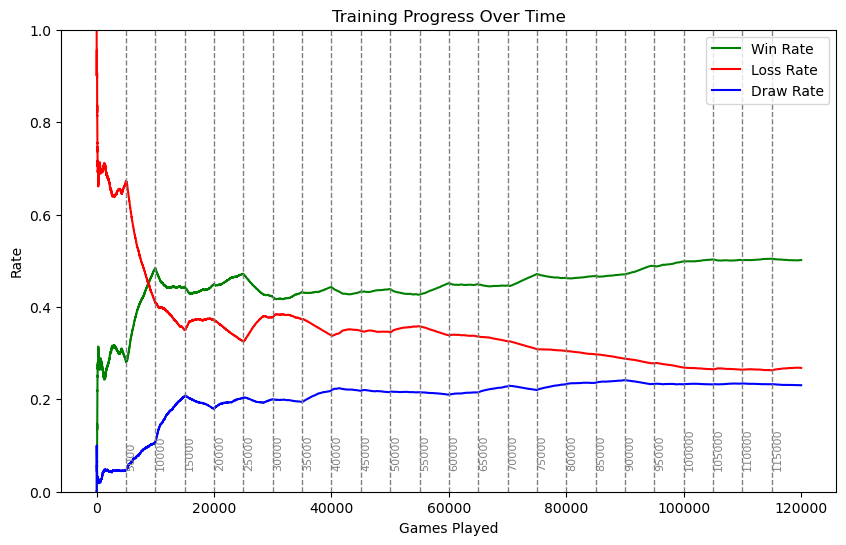

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(games, win_rate, label='Win Rate', color='green')
plt.plot(games, loss_rate, label='Loss Rate', color='red')
plt.plot(games, draw_rate, label='Draw Rate', color='blue')

# Add vertical lines every 5000 games
for milestone in range(5000, len(games), 5000):
    plt.axvline(x=milestone, color='gray', linestyle='--', linewidth=1)
    plt.text(milestone + 100, 0.05, f"{milestone}", rotation=90, color='gray', fontsize=8)

# Titles and labels
plt.title('Training Progress Over Time')
plt.xlabel('Games Played')
plt.ylabel('Rate')
plt.ylim(0, 1)
plt.legend()
# plt.savefig('plots/training_progress.png')
plt.show()


## What is the model's preferred first move? 


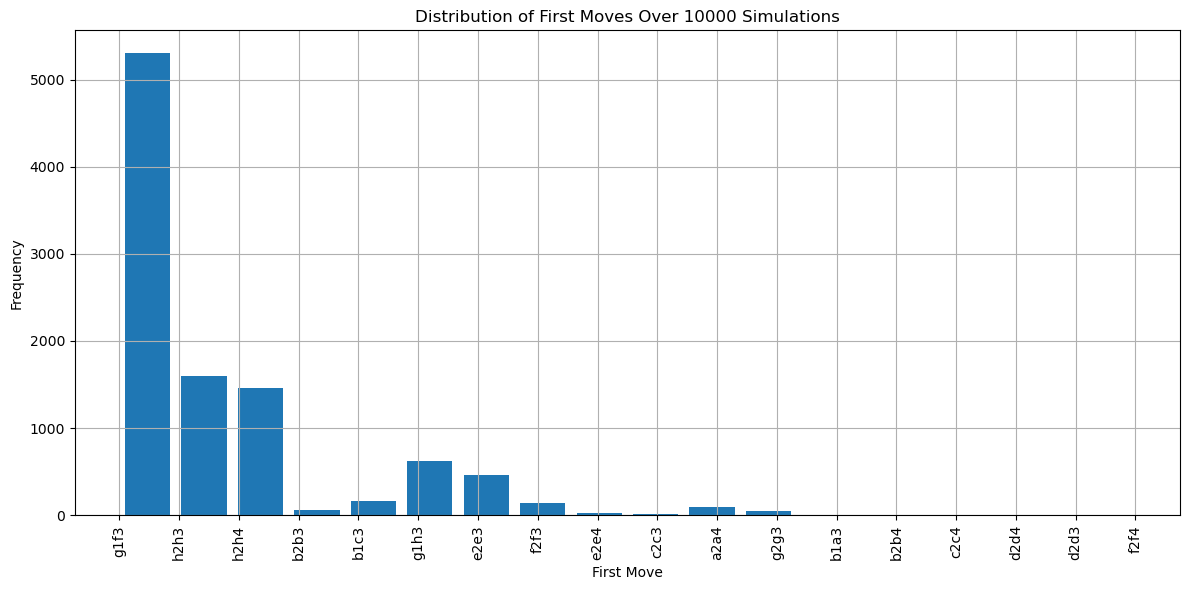

In [17]:
from homemade import MyLearningBot
simulations = 10000
first_moves = []

engine = MyLearningBot()

for i in range(simulations):
    board = chess.Board()
    result = engine.search(board)
    move = result.move
    first_moves.append(move.uci())

plt.figure(figsize=(12, 6))
plt.hist(first_moves, bins=len(set(first_moves)), rwidth=0.8)
plt.xticks(rotation=90)
plt.xlabel('First Move')
plt.ylabel('Frequency')
plt.title(f'Distribution of First Moves Over {simulations} Simulations')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
print("Model's top three openning moves:")

Model's top three openning moves:


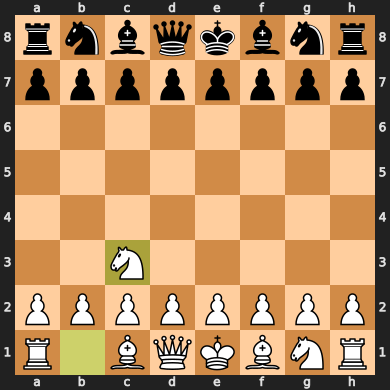

In [19]:
board = chess.Board()
move = chess.Move.from_uci("b1c3")
board.push(move)

board

In [20]:
print("Dunst Openning")

Dunst Openning


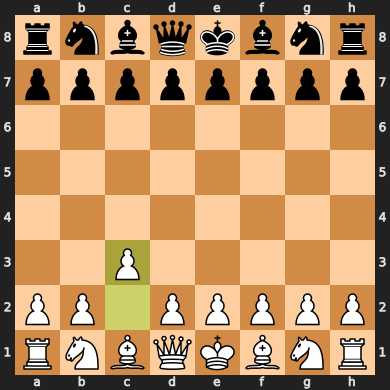

In [21]:
board = chess.Board()
move = chess.Move.from_uci("c2c3")
board.push(move)

board


In [22]:
print("The Saragossa Openning")

The Saragossa Openning


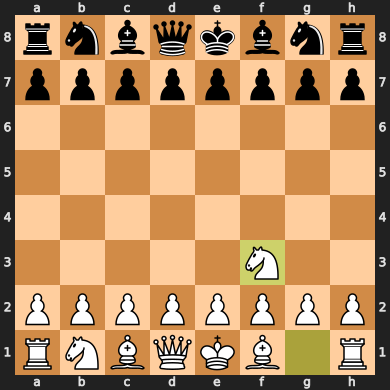

In [23]:
board = chess.Board()
Pf2f3 = chess.Move.from_uci("g1f3")
board.push(Pf2f3)

board

In [24]:
print("Reti Openning")

Reti Openning


#### Interactive!

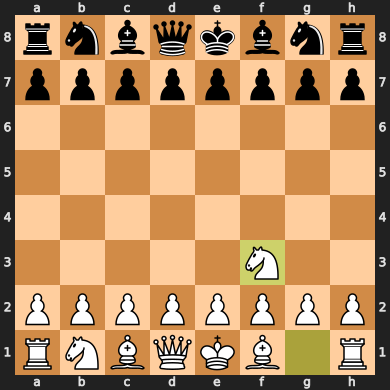

In [27]:
from homemade import MyLearningBot
engine = MyLearningBot()
board = chess.Board()

engine.search(board)
result = engine.search(board)
move = result.move
board.push(move)
board

In [44]:
board.push(chess.Move.from_uci("g1f1")) #g7g6, f8g7, g8f6, b7b5, b8c6, b5b4, b4c3, e8g8 # castling, 
engine.search(board)
result = engine.search(board)
move = result.move
board.push(move)
board

ValueError: zero-size array to reduction operation maximum which has no identity

# 6. Next Steps

* Increase Batch Size:
    * Train with a larger batch size so the model learns more effectively from each game's experiences.

* Expand Model Complexity:
    * Transition from a simple linear model to a deeper learning model (such as a small neural network) to capture non-linear relationships between board features and move quality.

* Train Against a More Advanced Opponent:
    * Introduce a stronger opponent that can challenge the agent more effectively as it improves.

* Benchmark Against Stronger Engines:
    * Evaluate the trained model’s performance against stronger external opponents to measure true playing strength.

* Deploy the Bot Online:
    * Connect the trained bot to Lichess or a similar platform to play real online games and further evaluate practical performance.

Thank you!